In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
# 시각화 스타일 설정 : 배경 흰색, 파스텔톤

sns.set_style('white')

sns.set_palette('deep')
# 한글 설정
plt.rcParams["font.family"] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False

In [135]:
df = pd.read_csv('data/music_streaming_habits_2026.csv')
df

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,26,France,Spotify,Family,Pop,SZA,197,55,6,15.3,False,Workout,True,False
3996,3997,35,Germany,YouTube Music,Free,Rock,Ariana Grande,320,77,13,9.2,True,Sad,False,True
3997,3998,43,India,Apple Music,Free,Hip-Hop,Dua Lipa,99,38,5,14.0,False,Happy,True,True
3998,3999,26,India,Apple Music,Student,Indie,SZA,76,31,7,36.1,False,Happy,False,False


In [136]:
data = df[['age','country','platform','top_genre','daily_listening_minutes','top_mood']]
data

,age,country,platform,top_genre,daily_listening_minutes,top_mood
0,24,Australia,Apple Music,R&B,191,Sleep
1,21,Germany,Spotify,Classical,249,Workout
2,32,Japan,Amazon Music,Hip-Hop,49,Sad
3,39,Japan,Apple Music,Pop,96,Sad
4,23,India,Spotify,Country,100,Workout
...,...,...,...,...,...,...
3995,26,France,Spotify,Pop,197,Workout
3996,35,Germany,YouTube Music,Rock,320,Sad
3997,43,India,Apple Music,Hip-Hop,99,Happy
3998,26,India,Apple Music,Indie,76,Happy


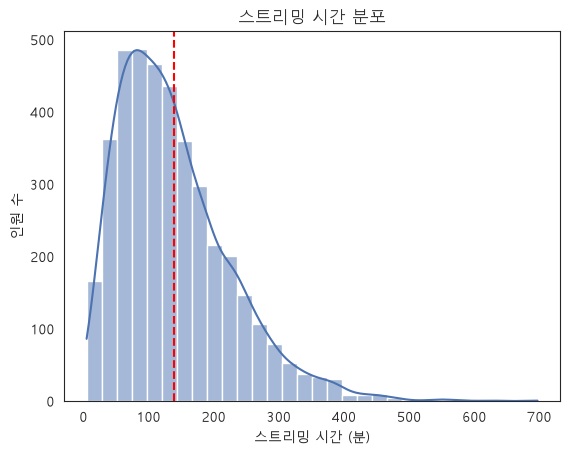

In [ ]:
# 인원별 스트리밍 시간 분포

sns.histplot(data=data, x='daily_listening_minutes', kde=True, bins=30)
plt.axvline(data['daily_listening_minutes'].mean(), linestyle='--', color='red')
plt.xlabel('스트리밍 시간 (분)')
plt.ylabel('인원 수')
plt.title('스트리밍 시간 분포')
plt.show()

In [137]:
# data['country'].unique()
data['platform'].unique()

<StringArray>
[  'Apple Music',       'Spotify',  'Amazon Music',         'Tidal',
    'SoundCloud', 'YouTube Music']
Length: 6, dtype: str

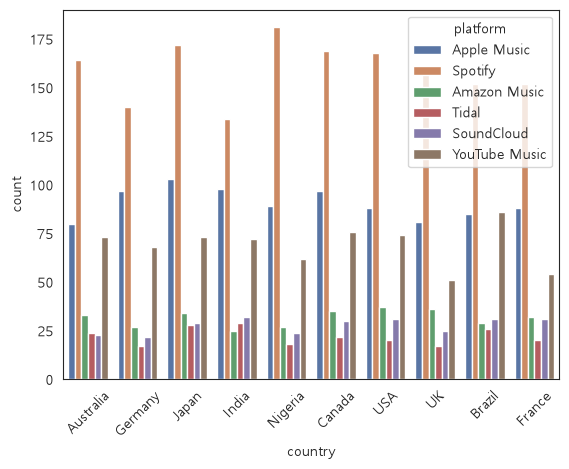

In [138]:
# 국가별 플랫폼 분포
# country_data = 
# sns.countplot(x = 'platform',data = data)
sns.countplot(data=data, x='country', hue='platform')
plt.xticks(rotation = 45)
plt.show()

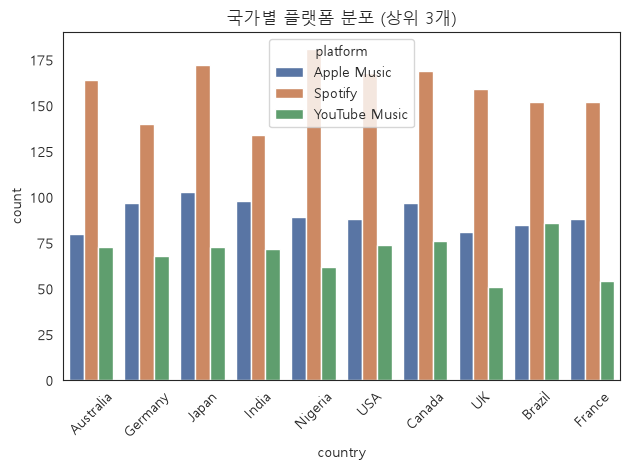

In [156]:
# 상위 3개 플랫폼만 뽑기
top3_platforms = data['platform'].value_counts().head(3).index
data_top3 = data[data['platform'].isin(top3_platforms)]

sns.countplot(data=data_top3, x='country', hue='platform')
plt.xticks(rotation=45)
plt.title('국가별 플랫폼 분포 (상위 3개)')
plt.tight_layout()
plt.show()

In [139]:
data

,age,country,platform,top_genre,daily_listening_minutes,top_mood
0,24,Australia,Apple Music,R&B,191,Sleep
1,21,Germany,Spotify,Classical,249,Workout
2,32,Japan,Amazon Music,Hip-Hop,49,Sad
3,39,Japan,Apple Music,Pop,96,Sad
4,23,India,Spotify,Country,100,Workout
...,...,...,...,...,...,...
3995,26,France,Spotify,Pop,197,Workout
3996,35,Germany,YouTube Music,Rock,320,Sad
3997,43,India,Apple Music,Hip-Hop,99,Happy
3998,26,India,Apple Music,Indie,76,Happy


Text(0.5, 1.0, '나이별 음악 스트리밍 시간')

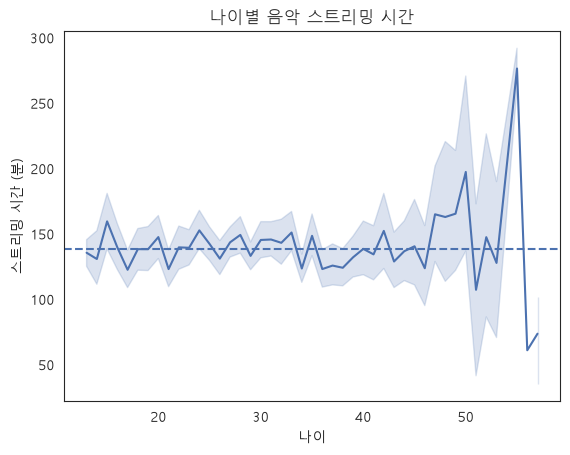

In [140]:
# 나이별 음악 스트리밍 선그래프 시각화

sns.lineplot(x = 'age', y = 'daily_listening_minutes',data = data)
plt.axhline(data['daily_listening_minutes'].mean(),linestyle = '--')
plt.xlabel("나이")
plt.ylabel("스트리밍 시간 (분)")
plt.title('나이별 음악 스트리밍 시간')

In [141]:
data['age'].describe()

count    4000.000000
mean       27.849000
std         8.595881
min        13.000000
25%        22.000000
50%        28.000000
75%        34.000000
max        57.000000
Name: age, dtype: float64

In [142]:
data = data.assign(
    agetype = np.where(
        data['age'] < 10,'child',   # 데이터 나이 30 미만 청년층
        np.where(
            data['age'] <20 ,'10th',
            np.where(
                data['age']<30,'20th',
                    np.where(
                        data['age']<40,'30th',
                        np.where(
                            data['age']<50,'40th',
                        'senior'
                        )
                    )
            )

        )
    )
)
data

,age,country,platform,top_genre,daily_listening_minutes,top_mood,agetype
0,24,Australia,Apple Music,R&B,191,Sleep,20th
1,21,Germany,Spotify,Classical,249,Workout,20th
2,32,Japan,Amazon Music,Hip-Hop,49,Sad,30th
3,39,Japan,Apple Music,Pop,96,Sad,30th
4,23,India,Spotify,Country,100,Workout,20th
...,...,...,...,...,...,...,...
3995,26,France,Spotify,Pop,197,Workout,20th
3996,35,Germany,YouTube Music,Rock,320,Sad,30th
3997,43,India,Apple Music,Hip-Hop,99,Happy,40th
3998,26,India,Apple Music,Indie,76,Happy,20th


Text(0.5, 1.0, '연령대별 스트리밍 수')

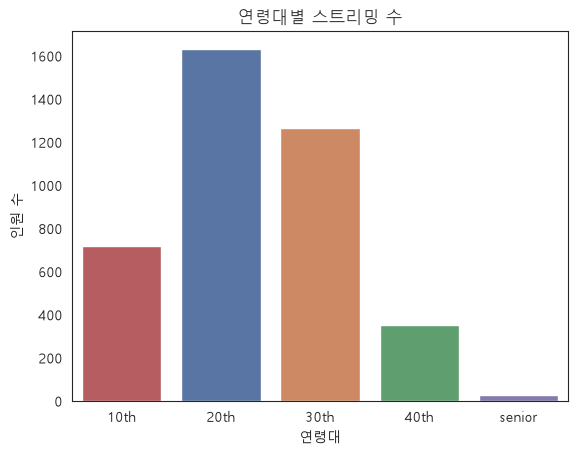

In [149]:
order = ['10th', '20th', '30th', '40th', 'senior']
sns.countplot(x = 'agetype',data =data,order = order,hue= 'agetype')
plt.xlabel('연령대')
plt.ylabel('인원 수')
plt.title("연령대별 스트리밍 수")

In [144]:
data

,age,country,platform,top_genre,daily_listening_minutes,top_mood,agetype
0,24,Australia,Apple Music,R&B,191,Sleep,20th
1,21,Germany,Spotify,Classical,249,Workout,20th
2,32,Japan,Amazon Music,Hip-Hop,49,Sad,30th
3,39,Japan,Apple Music,Pop,96,Sad,30th
4,23,India,Spotify,Country,100,Workout,20th
...,...,...,...,...,...,...,...
3995,26,France,Spotify,Pop,197,Workout,20th
3996,35,Germany,YouTube Music,Rock,320,Sad,30th
3997,43,India,Apple Music,Hip-Hop,99,Happy,40th
3998,26,India,Apple Music,Indie,76,Happy,20th


<Axes: xlabel='top_genre', ylabel='count'>

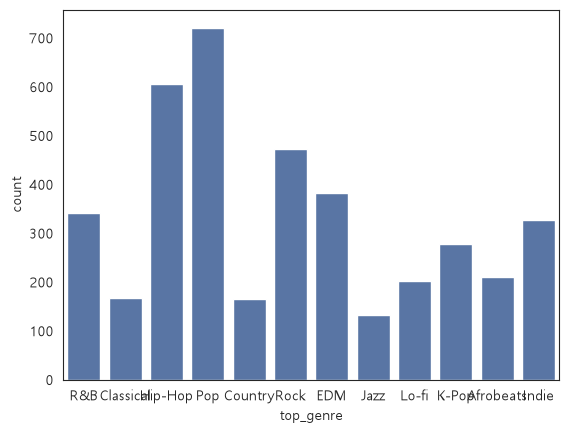

In [ ]:
sns.countplot( x = 'top_genre',data = data)


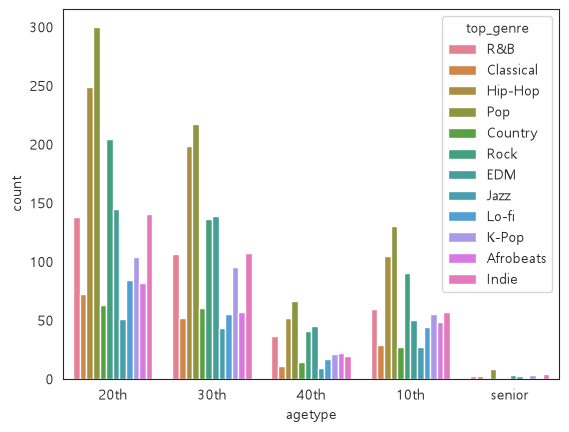

In [146]:
# 연령대별 좋아하는 장르 시각화

sns.countplot(data=data, x='agetype', hue='top_genre')
plt.show()

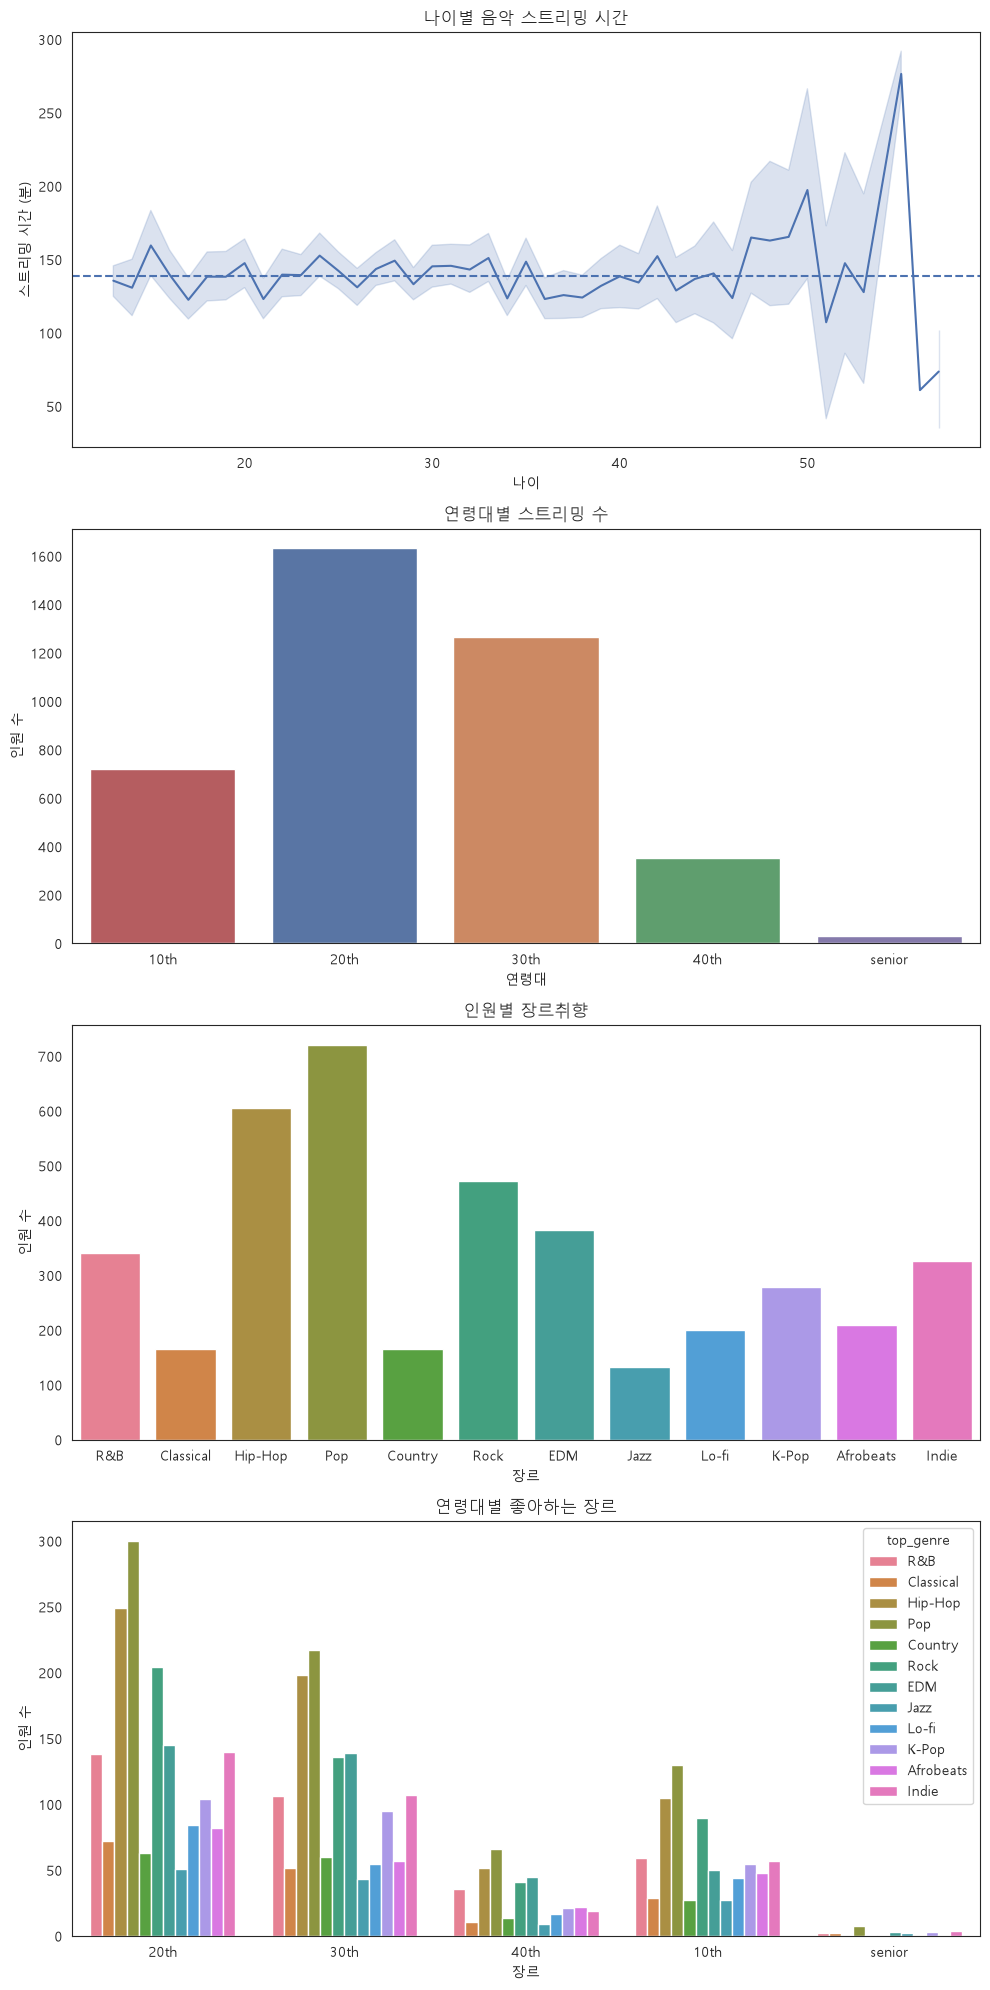

In [157]:
plt.figure(figsize=(10, 20))


# 나이별 음악 스트리밍 시간 시각화
plt.subplot(4, 1, 1)   
sns.lineplot(x = 'age', y = 'daily_listening_minutes',data = data)
plt.axhline(data['daily_listening_minutes'].mean(),linestyle = '--')
plt.xlabel("나이")
plt.ylabel("스트리밍 시간 (분)")
plt.title('나이별 음악 스트리밍 시간')

# 연령대별 스트리밍 수
plt.subplot(4, 1, 2)   
order = ['10th', '20th', '30th', '40th', 'senior']
sns.countplot(x = 'agetype',data =data,order = order, hue= 'agetype')
plt.xlabel('연령대')
plt.ylabel('인원 수')
plt.title("연령대별 스트리밍 수")

#장르 취향
plt.subplot(4, 1, 3)   
sns.countplot( x = 'top_genre',data = data, hue= 'top_genre')
plt.title("인원별 장르취향")
plt.xlabel('장르')
plt.ylabel('인원 수')

#연령대별 좋아하는 장르 시각화
plt.subplot(4, 1, 4)  
sns.countplot(data=data, x='agetype', hue='top_genre')
plt.title("연령대별 좋아하는 장르")
plt.xlabel('장르')
plt.ylabel('인원 수')


plt.tight_layout()      
plt.show()